# 🩻 Robust Multi-Architecture Ensemble for Pneumonia Detection
### ViT-B/16 + DenseNet-121 + Swin Transformer — Soft-Voting Ensemble

This notebook upgrades the original single-model (ViT-B/16) pipeline into a **three-model ensemble**:

| Model | Family | Role |
|---|---|---|
| **ViT-B/16** | Pure Transformer | MAE-pretrained on lung anatomy, global context |
| **DenseNet-121** | Convolutional (CNN) | Dense local feature reuse, strong texture/edge detector |
| **Swin Transformer (swin_tiny)** | Hierarchical Transformer | Windowed attention, multi-scale features |

All three models keep the **same adversarial training (FGSM/PGD) and evaluation protocol** as the original notebook, then are combined at inference time via **soft voting** (averaging softmax probabilities). Combining architecturally diverse models tends to reduce correlated errors and improve both clean accuracy and adversarial robustness versus any single model.

**What's preserved from your original notebook:**
- Kaggle chest X-ray dataset download & binary (NORMAL/PNEUMONIA) labeling
- Stratified 70/15/15 train/val/test split
- MAE self-supervised pretraining of the ViT encoder on lung anatomy
- FGSM + PGD adversarial training and evaluation
- AUROC, Expected Calibration Error (ECE), confusion matrix, ROC curves
- Single-image clinical-style inference report

**What's new:**
- DenseNet-121 and Swin-Tiny classifier heads, trained with the same adversarial regime
- A unified `train_one_model()` routine so all three models share identical training logic
- Soft-voting ensemble evaluation (clean / FGSM / PGD) compared against each individual model
- Per-model and ensemble confusion matrices, ROC curves, and calibration
- Ensemble-based single-image inference function


## 1. Setup & Environment

In [ ]:
!pip install torch torchvision timm transformers -q
!pip install scikit-learn matplotlib seaborn tqdm Pillow -q
!pip install torchattacks -q
!pip install grad-cam -q

import torch
import torch.nn as nn
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
warnings.filterwarnings('ignore')


SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device: {device}')
if device.type == 'cuda':
    print(f'🚀 GPU: {torch.cuda.get_device_name(0)}')
    print(f'💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.7/178.7 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.2/144.2 kB 14.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.25.1 which is incompatible.
libpysal 4.14.1 requires requests>=2.32.0, but you have requests 2.25.1 which is incompatible.
blobfile 3.2.0 requires urllib3>=2, but you have urllib3 1.26.20 which is incompatible.
yfinance 0.2.66 requires requests>=2.31, but you have requests 2.2

## 2. Dataset Download (Kaggle Chest X-Ray Pneumonia)

In [ ]:
import os
import zipfile
from google.colab import files
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from collections import Counter
from PIL import Image


if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("📥 Please upload your 'kaggle.json' credential file:")
    uploaded = files.upload()

    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("✅ Kaggle API Credentials Configured Successfully!")


print("🚀 Downloading Chest X-Ray Dataset from Kaggle...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia


print("📦 Unzipping dataset files...")
with zipfile.ZipFile('chest-xray-pneumonia.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/kaggle_chest_xray')

print("✅ Dataset extraction complete!")


📥 Please upload your 'kaggle.json' credential file:


Saving kaggle (2).json to kaggle (2).json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API Credentials Configured Successfully!
🚀 Downloading Chest X-Ray Dataset from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:18<00:00, 130MB/s]

📦 Unzipping dataset files...
✅ Dataset extraction complete!


In [ ]:
DATASET_PATH = '/content/kaggle_chest_xray/chest_xray'

CLASSES = ['normal', 'pneumonia']
EXTENSIONS = ('.jpg', '.jpeg', '.png')

image_paths, labels = [], []


for root, dirs, files in os.walk(DATASET_PATH):

    dirs[:] = [d for d in dirs if not d.startswith('__MACOSX')]
    for f in files:

        if f.startswith('._') or '__MACOSX' in root:
            continue

        if f.lower().endswith(EXTENSIONS):
            path = os.path.join(root, f)
            path_lower = path.lower()

            cls_found = next((c for c in CLASSES if c in path_lower), None)
            if cls_found:
                image_paths.append(path)
                labels.append(CLASSES.index(cls_found))

print(f'\n✅ Total images processed from Kaggle: {len(image_paths)}')
print(f'📊 Unified Binary Class Distribution:')
for i, cls_name in enumerate(CLASSES):
    print(f'   {cls_name.upper()}: {labels.count(i)} samples')



✅ Total images processed from Kaggle: 11712
📊 Unified Binary Class Distribution:
   NORMAL: 3166 samples
   PNEUMONIA: 8546 samples


In [ ]:
import pandas as pd

df = pd.DataFrame({'path': image_paths, 'label': labels})
df.head(100)


,path,label
0,/content/kaggle_chest_xray/chest_xray/val/NORM...,0
1,/content/kaggle_chest_xray/chest_xray/val/NORM...,0
2,/content/kaggle_chest_xray/chest_xray/val/NORM...,0
3,/content/kaggle_chest_xray/chest_xray/val/NORM...,0
4,/content/kaggle_chest_xray/chest_xray/val/NORM...,0
...,...,...
95,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
96,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
97,/content/kaggle_chest_xray/chest_xray/test/NOR...,0
98,/content/kaggle_chest_xray/chest_xray/test/NOR...,0


## 3. Stratified Splits & Datasets

In [ ]:
class PneumoniaDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]

indices = list(range(len(image_paths)))
train_idx, temp_idx = train_test_split(indices, test_size=0.30, random_state=SEED, stratify=labels)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.50, random_state=SEED, stratify=[labels[i] for i in temp_idx])

print(f'\n✅ Scientific Partitioning:')
print(f'   ↳ Training Pool   : {len(train_idx)} images')
print(f'   ↳ Validation Pool : {len(val_idx)} images')
print(f'   ↳ Evaluation Pool : {len(test_idx)} images')



✅ Scientific Partitioning:
   ↳ Training Pool   : 8198 images
   ↳ Validation Pool : 1757 images
   ↳ Evaluation Pool : 1757 images


## 4. Transforms & DataLoaders

Identical augmentation pipeline for every backbone — this keeps comparisons fair, since all three models see the exact same training distribution and the exact same val/test images.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), scale=(0.95, 1.05)),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def make_subset(idx_list, transform):
    return PneumoniaDataset(
        [image_paths[i] for i in idx_list],
        [labels[i] for i in idx_list],
        transform
    )

train_labels = [labels[i] for i in train_idx]
class_counts = Counter(train_labels)
class_weights = {cls: 1.0/count for cls, count in class_counts.items()}
sample_weights = [class_weights[l] for l in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

train_dataset = make_subset(train_idx, train_transform)
val_dataset = make_subset(val_idx, val_transform)
test_dataset = make_subset(test_idx, val_transform)


train_loader = DataLoader(train_dataset, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print('✅ DataLoaders ready!')
print(f'   Train batches : {len(train_loader)}')
print(f'   Val batches   : {len(val_loader)}')
print(f'   Test batches  : {len(test_loader)}')


✅ DataLoaders ready!
   Train batches : 257
   Val batches   : 55
   Test batches  : 55


## 5. MAE Self-Supervised Pretraining (ViT encoder only)

This stage is **unchanged** from the original notebook. DenseNet-121 and Swin both already ship with strong ImageNet pretraining and don't use the patch-based MAE objective used here (which is ViT-specific — it masks and reconstructs 16×16 image patches through a plain transformer encoder). The MAE-pretrained encoder gives the ViT branch a lung-anatomy-aware initialization before adversarial fine-tuning, exactly as before.

In [ ]:
import torch
import torch.nn as nn
import timm
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from tqdm import tqdm
from collections import Counter

class MaskedAutoEncoder(nn.Module):
    """
    True MAE: Converts images to patches, randomly masks them,
    and predicts the missing pixel values to learn anatomy.
    """
    def __init__(self, mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio

        self.encoder = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)
        embed_dim = self.encoder.embed_dim

        self.decoder = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.GELU(),
            nn.Linear(embed_dim * 2, 16 * 16 * 3)
        )

    def patchify(self, imgs):
        """Splits an image [B, 3, 224, 224] into flat pixel patches [B, 196, 768]"""
        p = 16
        h = w = 224 // p
        x = imgs.reshape(shape=(imgs.shape[0], 3, h, p, w, p))
        x = torch.einsum('nchpwq->nhwpqc', x)
        x = x.reshape(shape=(imgs.shape[0], h * w, p * p * 3))
        return x

    def random_masking(self, x):
        B, N, D = x.shape
        keep_len = int(N * (1 - self.mask_ratio))

        noise = torch.rand(B, N, device=x.device)
        ids_sort = torch.argsort(noise, dim=1)
        ids_keep = ids_sort[:, :keep_len]

        x_masked = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))
        return x_masked, ids_sort, keep_len

    def forward(self, imgs):
        target = self.patchify(imgs)

        x = self.encoder.patch_embed(imgs)
        x = x + self.encoder.pos_embed[:, 1:, :]

        x_masked, ids_sort, keep_len = self.random_masking(x)
        for blk in self.encoder.blocks:
            x_masked = blk(x_masked)
        x_masked = self.encoder.norm(x_masked)

        pred = self.decoder(x_masked)

        return pred, target, ids_sort, keep_len



def pretrain_mae(model, dataloader, epochs=3):
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.05)
    model.train()

    print('🧠 MAE Pre-training on Pulmonary Structures started...')
    for epoch in range(epochs):
        total_loss = 0

        for imgs, _ in tqdm(dataloader, desc=f'MAE Epoch {epoch+1}/{epochs}', leave=False):
            imgs = imgs.to(device)
            optimizer.zero_grad()

            pred, target, ids_sort, keep_len = model(imgs)

            ids_keep = ids_sort[:, :keep_len]
            target_visible = torch.gather(target, 1, ids_keep.unsqueeze(-1).expand(-1, -1, target.shape[-1]))

            loss = nn.functional.mse_loss(pred, target_visible)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f'   Epoch {epoch+1}: Loss = {total_loss/len(dataloader):.4f}')

    print('✅ MAE Pre-training complete!')
    return model.encoder


print('Building MAE model...')
mae_model = MaskedAutoEncoder(mask_ratio=0.75).to(device)

train_labels_for_sampler = [labels[i] for i in train_idx]
class_counts_for_sampler = Counter(train_labels_for_sampler)
class_weights_for_sampler = {cls: 1.0/count for cls, count in class_counts_for_sampler.items()}
sample_weights_for_sampler = [class_weights_for_sampler[l] for l in train_labels_for_sampler]
sampler_for_mae = WeightedRandomSampler(sample_weights_for_sampler, len(sample_weights_for_sampler))

train_dataset_for_mae = PneumoniaDataset(
    [image_paths[i] for i in train_idx],
    [labels[i] for i in train_idx],
    train_transform
)
train_loader_for_mae = DataLoader(train_dataset_for_mae, batch_size=32, sampler=sampler_for_mae, num_workers=2, pin_memory=True, persistent_workers=True)

pretrained_encoder = pretrain_mae(mae_model, train_loader_for_mae, epochs=3)

from google.colab import drive
drive.mount('/content/drive')

torch.save(pretrained_encoder.state_dict(), '/content/drive/MyDrive/mae_pneumonia_encoder.pth')
print('✅ Pre-trained encoder saved to Drive!')


Building MAE model...


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

🧠 MAE Pre-training on Pulmonary Structures started...


   Epoch 1: Loss = 0.1666


   Epoch 2: Loss = 0.0307


   Epoch 3: Loss = 0.0201
✅ MAE Pre-training complete!
Mounted at /content/drive
✅ Pre-trained encoder saved to Drive!


## 6. Model Definitions — Three Architectures

Each model exposes the same interface (`forward(x) -> logits`, `predict_with_uncertainty(x)` via MC Dropout) so they can be trained, attacked, evaluated, and ensembled with identical code.

- **`PneumoniaViT`** — ViT-B/16, MAE-pretrained backbone, first 3 transformer blocks frozen (unchanged from original).
- **`PneumoniaDenseNet`** — DenseNet-121, ImageNet-pretrained, early dense blocks frozen. CNNs pick up local texture cues (e.g. consolidation patterns) that complement a transformer's global attention.
- **`PneumoniaSwin`** — Swin-Tiny, ImageNet-pretrained, early stages frozen. Hierarchical windowed attention gives it multi-scale spatial features distinct from both ViT and DenseNet.

In [ ]:
class PneumoniaViT(nn.Module):
    """
    Vision Transformer tailored for binary classification (Normal vs Pneumonia).
    Includes Monte Carlo (MC) Dropout for predictive clinical uncertainty estimation.
    """
    def __init__(self, num_classes=2, pretrained_encoder=None, dropout=0.1):
        super().__init__()
        self.backbone = timm.create_model('vit_base_patch16_224', pretrained=True, num_classes=0)

        if pretrained_encoder is not None:
            print('Loading MAE lung-pre-trained weights into ViT backbone...')
            self.backbone.load_state_dict(pretrained_encoder.state_dict(), strict=False)

        embed_dim = self.backbone.embed_dim

        for name, param in self.backbone.named_parameters():
            if any(f'blocks.{i}.' in name for i in range(3)):
                param.requires_grad = False

        self.head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out

    def predict_with_uncertainty(self, x, n_samples=10):
        """MC Dropout — runs forward pass multiple times to compute predictive entropy."""
        self.train()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(x)
                preds.append(torch.softmax(out, dim=1))
        mean_preds = torch.stack(preds).mean(0)
        uncertainty = -(mean_preds * mean_preds.log().clamp(-10, 0)).sum(1)
        self.eval()
        return mean_preds, uncertainty


class PneumoniaDenseNet(nn.Module):
    """
    DenseNet-121 tailored for binary classification (Normal vs Pneumonia).
    Dense connectivity reuses low-level texture features across layers — a strong
    complement to a pure-attention model like ViT. Same MC-Dropout uncertainty API.
    """
    def __init__(self, num_classes=2, dropout=0.1):
        super().__init__()
        self.backbone = timm.create_model('densenet121', pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        # Freeze the earliest dense blocks (low-level edge/texture filters transfer well as-is)
        for name, param in self.backbone.named_parameters():
            if 'features.conv0' in name or 'features.norm0' in name or 'denseblock1' in name:
                param.requires_grad = False

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out

    def predict_with_uncertainty(self, x, n_samples=10):
        self.train()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(x)
                preds.append(torch.softmax(out, dim=1))
        mean_preds = torch.stack(preds).mean(0)
        uncertainty = -(mean_preds * mean_preds.log().clamp(-10, 0)).sum(1)
        self.eval()
        return mean_preds, uncertainty


class PneumoniaSwin(nn.Module):
    """
    Swin-Tiny (hierarchical windowed-attention transformer) tailored for binary
    classification (Normal vs Pneumonia). Multi-scale features differ from both
    the plain ViT and the CNN, helping diversify ensemble errors. Same MC-Dropout API.
    """
    def __init__(self, num_classes=2, dropout=0.1):
        super().__init__()
        self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        feat_dim = self.backbone.num_features

        # Freeze the first two stages (general low/mid-level visual features)
        for name, param in self.backbone.named_parameters():
            if 'layers.0.' in name or 'layers.1.' in name or 'patch_embed' in name:
                param.requires_grad = False

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.backbone(x)
        out = self.head(features)
        return out

    def predict_with_uncertainty(self, x, n_samples=10):
        self.train()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                out = self.forward(x)
                preds.append(torch.softmax(out, dim=1))
        mean_preds = torch.stack(preds).mean(0)
        uncertainty = -(mean_preds * mean_preds.log().clamp(-10, 0)).sum(1)
        self.eval()
        return mean_preds, uncertainty


vit_model = PneumoniaViT(pretrained_encoder=pretrained_encoder).to(device)
densenet_model = PneumoniaDenseNet().to(device)
swin_model = PneumoniaSwin().to(device)

for name, m in [('ViT-B/16', vit_model), ('DenseNet-121', densenet_model), ('Swin-Tiny', swin_model)]:
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'✅ {name:<14} | Total params: {total:>12,} | Trainable params: {trainable:>12,}')


Loading MAE lung-pre-trained weights into ViT backbone...


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

✅ ViT-B/16       | Total params:   85,997,570 | Trainable params:   64,733,954
✅ DenseNet-121   | Total params:    7,218,818 | Trainable params:    6,874,242
✅ Swin-Tiny      | Total params:   27,718,268 | Trainable params:   26,522,426


## 7. Adversarial Attack Modules (FGSM / PGD)

Unchanged — shared by all three models during training and evaluation.

In [ ]:
def fgsm_attack(model, images, labels, epsilon=0.03):
    """FGSM — Fast Gradient Sign Method generation."""
    images.requires_grad = True
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    model.zero_grad()
    loss.backward()
    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)
    return adv_images.detach()

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.007, steps=10):
    """PGD — Projected Gradient Descent (Strong iterative optimization)."""
    adv_images = images.clone().detach() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    adv_images = torch.clamp(adv_images, 0, 1)

    for _ in range(steps):
        adv_images.requires_grad = True
        outputs = model(adv_images)
        loss = nn.CrossEntropyLoss()(outputs, labels)
        model.zero_grad()
        loss.backward()
        adv_images = adv_images + alpha * adv_images.grad.sign()
        delta = torch.clamp(adv_images - images, -epsilon, epsilon)
        adv_images = torch.clamp(images + delta, 0, 1).detach()

    return adv_images

print('✅ Defensive Attack modules initialized!')


✅ Defensive Attack modules initialized!


In [ ]:
class DomainGeneralizationMixin:
    """Test-Time Augmentation (TTA) to emulate robust cross-hospital testing."""
    @staticmethod
    def tta_predict(model, image_tensor, n_augments=4):
        tta_transforms = [
            transforms.Compose([transforms.RandomHorizontalFlip(p=1.0)]),
            transforms.Compose([transforms.RandomRotation(10)]),
            transforms.Compose([transforms.ColorJitter(brightness=0.15)]),
        ]
        model.eval()
        preds = []
        with torch.no_grad():
            out = model(image_tensor)
            preds.append(torch.softmax(out, dim=1))
        for t in tta_transforms:
            aug_img = t(image_tensor)
            with torch.no_grad():
                out = model(aug_img)
                preds.append(torch.softmax(out, dim=1))
        return torch.stack(preds).mean(0)

print('✅ Test-Time Augmentation Framework ready.')


✅ Test-Time Augmentation Framework ready.


## 8. Unified Adversarial Training Loop

This is the same `adversarial_train_fast` logic as the original notebook, refactored into a single reusable function (`train_one_model`) so ViT, DenseNet, and Swin are all trained with **identical hyperparameters, schedule, and adversarial mixing** — the only thing that differs between runs is the model and its checkpoint path. This keeps the eventual ensemble comparison fair: any accuracy difference between backbones reflects architecture, not training recipe.

In [ ]:
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.cuda.amp import GradScaler, autocast

def train_one_model(model, model_name, train_loader, val_loader, epochs=15, adv_ratio=0.5, lr=2e-5, save_path=None):
    """
    Shared adversarial fine-tuning loop for any of the three backbones.
    Mixes clean images with FGSM/PGD adversarial images each batch, exactly
    as in the original single-model notebook.
    """
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    scaler = GradScaler()

    history = {'train_loss': [], 'val_acc': []}
    best_val_acc = 0

    print(f'🚀 Commencing Accelerated Defensive Fine-tuning Loop for {model_name}...')

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        correct = total = 0

        for batch_idx, (imgs, lbls) in enumerate(tqdm(train_loader, desc=f'[{model_name}] Epoch {epoch+1}/{epochs}', leave=False)):
            imgs = imgs.to(device, non_blocking=True)
            lbls = lbls.to(device, non_blocking=True)

            if batch_idx % 2 == 0:
                adv_imgs = fgsm_attack(model, imgs.clone(), lbls, epsilon=0.03)
            else:
                adv_imgs = pgd_attack(model, imgs.clone(), lbls, epsilon=0.03, alpha=0.015, steps=1)

            split = int(len(imgs) * (1 - adv_ratio))
            mixed_imgs = torch.cat([imgs[:split], adv_imgs[split:]], dim=0)

            optimizer.zero_grad()

            with autocast():
                outputs = model(mixed_imgs)
                loss = criterion(outputs, lbls)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()
            correct += (outputs.argmax(1) == lbls).sum().item()
            total += len(imgs)

        scheduler.step()

        model.eval()
        val_correct = val_total = 0
        with torch.no_grad():
            with autocast():
                for val_imgs, val_lbls in val_loader:
                    val_imgs = val_imgs.to(device, non_blocking=True)
                    val_lbls = val_lbls.to(device, non_blocking=True)
                    val_outputs = model(val_imgs)
                    val_correct += (val_outputs.argmax(1) == val_lbls).sum().item()
                    val_total += len(val_imgs)

        val_acc = 100 * val_correct / val_total
        history['train_loss'].append(total_loss / len(train_loader))
        history['val_acc'].append(val_acc)

        print(f'[{model_name}] Epoch [{epoch+1:2d}/{epochs}] | Loss: {total_loss/len(train_loader):.3f} | Val Accuracy: {val_acc:.1f}%')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f'   💾 [{model_name}] Model checkpoint updated! Acc: {best_val_acc:.1f}%')

    print(f'\n🏆 [{model_name}] Optimal Validation Accuracy Reached: {best_val_acc:.1f}%')
    return history


In [ ]:
# Checkpoint paths for each backbone
VIT_PATH = '/content/drive/MyDrive/best_pneumonia_vit.pth'
DENSENET_PATH = '/content/drive/MyDrive/best_pneumonia_densenet.pth'
SWIN_PATH = '/content/drive/MyDrive/best_pneumonia_swin.pth'

EPOCHS = 15

vit_history = train_one_model(vit_model, 'ViT-B/16', train_loader, val_loader, epochs=EPOCHS, save_path=VIT_PATH)


🚀 Commencing Accelerated Defensive Fine-tuning Loop for ViT-B/16...


[ViT-B/16] Epoch [ 1/15] | Loss: 0.634 | Val Accuracy: 88.9%
   💾 [ViT-B/16] Model checkpoint updated! Acc: 88.9%


[ViT-B/16] Epoch [ 2/15] | Loss: 0.452 | Val Accuracy: 93.1%
   💾 [ViT-B/16] Model checkpoint updated! Acc: 93.1%


[ViT-B/16] Epoch [ 3/15] | Loss: 0.403 | Val Accuracy: 88.0%


[ViT-B/16] Epoch [ 4/15] | Loss: 0.382 | Val Accuracy: 94.3%
   💾 [ViT-B/16] Model checkpoint updated! Acc: 94.3%


...

[ViT-B/16] Epoch [11/15] | Loss: 0.316 | Val Accuracy: 95.6%


[ViT-B/16] Epoch [12/15] | Loss: 0.308 | Val Accuracy: 96.2%
   💾 [ViT-B/16] Model checkpoint updated! Acc: 96.2%


[ViT-B/16] Epoch [13/15] | Loss: 0.305 | Val Accuracy: 96.1%


[ViT-B/16] Epoch [14/15] | Loss: 0.301 | Val Accuracy: 95.6%


[ViT-B/16] Epoch [15/15] | Loss: 0.300 | Val Accuracy: 95.7%

🏆 [ViT-B/16] Optimal Validation Accuracy Reached: 96.2%


In [ ]:
densenet_history = train_one_model(densenet_model, 'DenseNet-121', train_loader, val_loader, epochs=EPOCHS, save_path=DENSENET_PATH)


🚀 Commencing Accelerated Defensive Fine-tuning Loop for DenseNet-121...


[DenseNet-121] Epoch [ 1/15] | Loss: 0.507 | Val Accuracy: 94.8%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 94.8%


[DenseNet-121] Epoch [ 2/15] | Loss: 0.378 | Val Accuracy: 94.4%


[DenseNet-121] Epoch [ 3/15] | Loss: 0.352 | Val Accuracy: 96.3%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 96.3%


[DenseNet-121] Epoch [ 4/15] | Loss: 0.330 | Val Accuracy: 94.8%


...

[DenseNet-121] Epoch [11/15] | Loss: 0.291 | Val Accuracy: 97.8%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 97.8%


[DenseNet-121] Epoch [12/15] | Loss: 0.288 | Val Accuracy: 97.2%


[DenseNet-121] Epoch [13/15] | Loss: 0.291 | Val Accuracy: 98.1%
   💾 [DenseNet-121] Model checkpoint updated! Acc: 98.1%


[DenseNet-121] Epoch [14/15] | Loss: 0.283 | Val Accuracy: 97.3%


[DenseNet-121] Epoch [15/15] | Loss: 0.286 | Val Accuracy: 97.1%

🏆 [DenseNet-121] Optimal Validation Accuracy Reached: 98.1%


In [ ]:
swin_history = train_one_model(swin_model, 'Swin-Tiny', train_loader, val_loader, epochs=EPOCHS, save_path=SWIN_PATH)


🚀 Commencing Accelerated Defensive Fine-tuning Loop for Swin-Tiny...


[Swin-Tiny] Epoch [ 1/15] | Loss: 0.510 | Val Accuracy: 95.7%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 95.7%


[Swin-Tiny] Epoch [ 2/15] | Loss: 0.424 | Val Accuracy: 96.9%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 96.9%


[Swin-Tiny] Epoch [ 3/15] | Loss: 0.385 | Val Accuracy: 97.8%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 97.8%


[Swin-Tiny] Epoch [ 4/15] | Loss: 0.365 | Val Accuracy: 96.3%


...

[Swin-Tiny] Epoch [11/15] | Loss: 0.310 | Val Accuracy: 98.6%
   💾 [Swin-Tiny] Model checkpoint updated! Acc: 98.6%


[Swin-Tiny] Epoch [12/15] | Loss: 0.302 | Val Accuracy: 98.1%


[Swin-Tiny] Epoch [13/15] | Loss: 0.305 | Val Accuracy: 98.1%


[Swin-Tiny] Epoch [14/15] | Loss: 0.306 | Val Accuracy: 98.3%


[Swin-Tiny] Epoch [15/15] | Loss: 0.303 | Val Accuracy: 98.3%

🏆 [Swin-Tiny] Optimal Validation Accuracy Reached: 98.6%


## 9. Load Best Checkpoints & Build the Soft-Voting Ensemble

**Soft voting** averages each model's predicted class *probabilities* (post-softmax), rather than averaging hard 0/1 predictions ("hard voting"). This preserves confidence information — if ViT is 95% sure and DenseNet is only 55% sure, the ensemble correctly leans toward ViT's prediction rather than treating both votes as equal. We use **equal weights (1/3 each)** by default; a weighted variant is shown afterward, optionally weighting by each model's clean validation accuracy.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Reload best checkpoints for each model
vit_model.load_state_dict(torch.load(VIT_PATH))
densenet_model.load_state_dict(torch.load(DENSENET_PATH))
swin_model.load_state_dict(torch.load(SWIN_PATH))

vit_model.eval()
densenet_model.eval()
swin_model.eval()

ENSEMBLE_MODELS = {
    'ViT-B/16': vit_model,
    'DenseNet-121': densenet_model,
    'Swin-Tiny': swin_model,
}

print('✅ All three best checkpoints loaded and set to eval mode.')


✅ All three best checkpoints loaded and set to eval mode.


In [ ]:
def ensemble_predict_proba(models_dict, images, weights=None):
    """
    Soft-voting: averages softmax probabilities across models.
    `weights` is an optional dict {model_name: weight}; defaults to equal weighting.
    Returns the averaged probability tensor of shape [B, num_classes].
    """
    names = list(models_dict.keys())
    if weights is None:
        weights = {n: 1.0 / len(names) for n in names}

    total_probs = None
    for name in names:
        model = models_dict[name]
        with torch.no_grad():
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
        weighted = probs * weights[name]
        total_probs = weighted if total_probs is None else total_probs + weighted

    return total_probs


def fgsm_attack_ensemble(models_dict, images, labels, epsilon=0.03, weights=None):
    """
    FGSM crafted against the ensemble's averaged loss (a stronger, more realistic
    attack than attacking a single member, since a real adversary attacking a
    deployed ensemble would target its combined decision).
    """
    images = images.clone().detach()
    images.requires_grad = True

    names = list(models_dict.keys())
    if weights is None:
        weights = {n: 1.0 / len(names) for n in names}

    total_loss = 0
    for name in names:
        model = models_dict[name]
        outputs = model(images)
        total_loss = total_loss + weights[name] * nn.CrossEntropyLoss()(outputs, labels)

    for model in models_dict.values():
        model.zero_grad()
    total_loss.backward()

    adv_images = images + epsilon * images.grad.sign()
    adv_images = torch.clamp(adv_images, 0, 1)
    return adv_images.detach()


def pgd_attack_ensemble(models_dict, images, labels, epsilon=0.03, alpha=0.007, steps=10, weights=None):
    """PGD crafted against the ensemble's averaged loss."""
    names = list(models_dict.keys())
    if weights is None:
        weights = {n: 1.0 / len(names) for n in names}

    adv_images = images.clone().detach() + torch.empty_like(images).uniform_(-epsilon, epsilon)
    adv_images = torch.clamp(adv_images, 0, 1)

    for _ in range(steps):
        adv_images.requires_grad = True
        total_loss = 0
        for name in names:
            model = models_dict[name]
            outputs = model(adv_images)
            total_loss = total_loss + weights[name] * nn.CrossEntropyLoss()(outputs, labels)

        for model in models_dict.values():
            model.zero_grad()
        total_loss.backward()

        adv_images = adv_images + alpha * adv_images.grad.sign()
        delta = torch.clamp(adv_images - images, -epsilon, epsilon)
        adv_images = torch.clamp(images + delta, 0, 1).detach()

    return adv_images

print('✅ Soft-voting ensemble & ensemble-aware attack functions ready.')


✅ Soft-voting ensemble & ensemble-aware attack functions ready.


## 10. Evaluation — Individual Models vs. Ensemble

We benchmark each model **and** the ensemble under three conditions, exactly as the original notebook did for the single ViT:
1. **Clean** — unperturbed test images
2. **FGSM** — single-step adversarial perturbation
3. **PGD** — strong iterative adversarial perturbation

For the ensemble, attacks are crafted against the ensemble's own combined loss (`*_attack_ensemble`), which is the realistic worst case for an attacker who knows an ensemble is deployed.

In [ ]:
def expected_calibration_error(probs, labels, n_bins=10):
    probs, labels = np.array(probs), np.array(labels)
    bins = np.linspace(0, 1, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        mask = (probs >= bins[i]) & (probs < bins[i+1])
        if mask.sum() > 0:
            acc = (labels[mask] == 1).mean()
            conf = probs[mask].mean()
            ece += mask.sum() * abs(acc - conf)
    return ece / len(probs)


def evaluate_single_model(model, loader, attack_fn=None, attack_name='Clean'):
    """Same evaluation routine as the original notebook, for one model."""
    all_preds, all_true, all_probs = [], [], []

    for imgs, lbls in tqdm(loader, desc=f'Evaluating [{attack_name}]'):
        imgs = imgs.to(device)
        lbls = lbls.to(device)

        if attack_fn:
            imgs = attack_fn(model, imgs, lbls)

        with torch.no_grad():
            outputs = model(imgs)
            probs = torch.softmax(outputs, dim=1)[:, 1]

        all_preds.extend(outputs.argmax(1).cpu().numpy())
        all_true.extend(lbls.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_true)) * 100
    try:
        auroc = roc_auc_score(all_true, all_probs) * 100
    except:
        auroc = 0.0

    return {'attack': attack_name, 'acc': acc, 'auroc': auroc,
            'preds': all_preds, 'true': all_true, 'probs': all_probs}


def evaluate_ensemble(models_dict, loader, attack_fn=None, attack_name='Clean', weights=None):
    """
    Same metrics as evaluate_single_model, but predictions come from
    soft-voted probabilities across all models in models_dict.
    """
    all_preds, all_true, all_probs = [], [], []

    for imgs, lbls in tqdm(loader, desc=f'Evaluating Ensemble [{attack_name}]'):
        imgs = imgs.to(device)
        lbls = lbls.to(device)

        if attack_fn:
            imgs = attack_fn(models_dict, imgs, lbls, weights=weights)

        probs_full = ensemble_predict_proba(models_dict, imgs, weights=weights)
        preds = probs_full.argmax(1)

        all_preds.extend(preds.cpu().numpy())
        all_true.extend(lbls.cpu().numpy())
        all_probs.extend(probs_full[:, 1].cpu().numpy())

    acc = np.mean(np.array(all_preds) == np.array(all_true)) * 100
    try:
        auroc = roc_auc_score(all_true, all_probs) * 100
    except:
        auroc = 0.0

    return {'attack': attack_name, 'acc': acc, 'auroc': auroc,
            'preds': all_preds, 'true': all_true, 'probs': all_probs}


In [ ]:
print('🔍 Benchmarking each individual model (Clean / FGSM / PGD)...\n')

individual_results = {}
for name, model in ENSEMBLE_MODELS.items():
    print(f'--- {name} ---')
    clean_r = evaluate_single_model(model, test_loader, attack_name='Clean')
    fgsm_r = evaluate_single_model(model, test_loader, attack_fn=lambda m,i,l: fgsm_attack(m,i,l), attack_name='FGSM')
    pgd_r = evaluate_single_model(model, test_loader, attack_fn=lambda m,i,l: pgd_attack(m,i,l), attack_name='PGD')
    individual_results[name] = {'Clean': clean_r, 'FGSM': fgsm_r, 'PGD': pgd_r}
    print(f'   Clean: {clean_r["acc"]:.1f}% acc, {clean_r["auroc"]:.1f}% AUROC')
    print(f'   FGSM : {fgsm_r["acc"]:.1f}% acc, {fgsm_r["auroc"]:.1f}% AUROC')
    print(f'   PGD  : {pgd_r["acc"]:.1f}% acc, {pgd_r["auroc"]:.1f}% AUROC\n')


🔍 Benchmarking each individual model (Clean / FGSM / PGD)...

--- ViT-B/16 ---


Evaluating [PGD]: 100%|██████████| 55/55 [11:22<00:00, 12.41s/it]


   Clean: 94.0% acc, 98.7% AUROC
   FGSM : 91.3% acc, 97.4% AUROC
   PGD  : 86.2% acc, 92.8% AUROC

--- DenseNet-121 ---


Evaluating [PGD]: 100%|██████████| 55/55 [02:49<00:00,  3.07s/it]


   Clean: 96.9% acc, 99.3% AUROC
   FGSM : 94.9% acc, 98.6% AUROC
   PGD  : 2.3% acc, 0.0% AUROC

--- Swin-Tiny ---


Evaluating [PGD]: 100%|██████████| 55/55 [04:17<00:00,  4.68s/it]

   Clean: 97.2% acc, 99.6% AUROC
   FGSM : 95.2% acc, 99.4% AUROC
   PGD  : 18.2% acc, 8.2% AUROC



In [ ]:
print('🔍 Benchmarking the Soft-Voting Ensemble (Clean / FGSM / PGD)...\n')

ens_clean = evaluate_ensemble(ENSEMBLE_MODELS, test_loader, attack_name='Clean')
ens_fgsm = evaluate_ensemble(ENSEMBLE_MODELS, test_loader, attack_fn=fgsm_attack_ensemble, attack_name='FGSM')
ens_pgd = evaluate_ensemble(ENSEMBLE_MODELS, test_loader, attack_fn=pgd_attack_ensemble, attack_name='PGD')

ensemble_results = {'Clean': ens_clean, 'FGSM': ens_fgsm, 'PGD': ens_pgd}
ens_ece = expected_calibration_error(ens_clean['probs'], ens_clean['true'])

print(f'   Clean: {ens_clean["acc"]:.1f}% acc, {ens_clean["auroc"]:.1f}% AUROC')
print(f'   FGSM : {ens_fgsm["acc"]:.1f}% acc, {ens_fgsm["auroc"]:.1f}% AUROC')
print(f'   PGD  : {ens_pgd["acc"]:.1f}% acc, {ens_pgd["auroc"]:.1f}% AUROC')
print(f'   ECE  : {ens_ece:.4f}')


🔍 Benchmarking the Soft-Voting Ensemble (Clean / FGSM / PGD)...



Evaluating Ensemble [PGD]: 100%|██████████| 55/55 [18:27<00:00, 20.14s/it]

   Clean: 96.9% acc, 99.4% AUROC
   FGSM : 94.3% acc, 98.8% AUROC
   PGD  : 75.1% acc, 71.1% AUROC
   ECE  : 0.0668


In [ ]:
print('=' * 78)
print('📊 FULL COMPARISON TABLE — INDIVIDUAL MODELS vs. SOFT-VOTING ENSEMBLE')
print('=' * 78)
header = f'{"Model":<16} {"Clean Acc":>10} {"Clean AUROC":>12} {"FGSM Acc":>10} {"PGD Acc":>10}'
print(header)
print('-' * 78)
for name, res in individual_results.items():
    print(f'{name:<16} {res["Clean"]["acc"]:>9.1f}% {res["Clean"]["auroc"]:>11.1f}% {res["FGSM"]["acc"]:>9.1f}% {res["PGD"]["acc"]:>9.1f}%')
print('-' * 78)
print(f'{"ENSEMBLE (Soft)":<16} {ensemble_results["Clean"]["acc"]:>9.1f}% {ensemble_results["Clean"]["auroc"]:>11.1f}% {ensemble_results["FGSM"]["acc"]:>9.1f}% {ensemble_results["PGD"]["acc"]:>9.1f}%')
print('=' * 78)


📊 FULL COMPARISON TABLE — INDIVIDUAL MODELS vs. SOFT-VOTING ENSEMBLE
Model             Clean Acc  Clean AUROC   FGSM Acc    PGD Acc
------------------------------------------------------------------------------
ViT-B/16              94.0%        98.7%      91.3%      86.2%
DenseNet-121          96.9%        99.3%      94.9%       2.3%
Swin-Tiny             97.2%        99.6%      95.2%      18.2%
------------------------------------------------------------------------------
ENSEMBLE (Soft)       96.9%        99.4%      94.3%      75.1%


## 12. Visualization — Per-Model & Ensemble Comparison

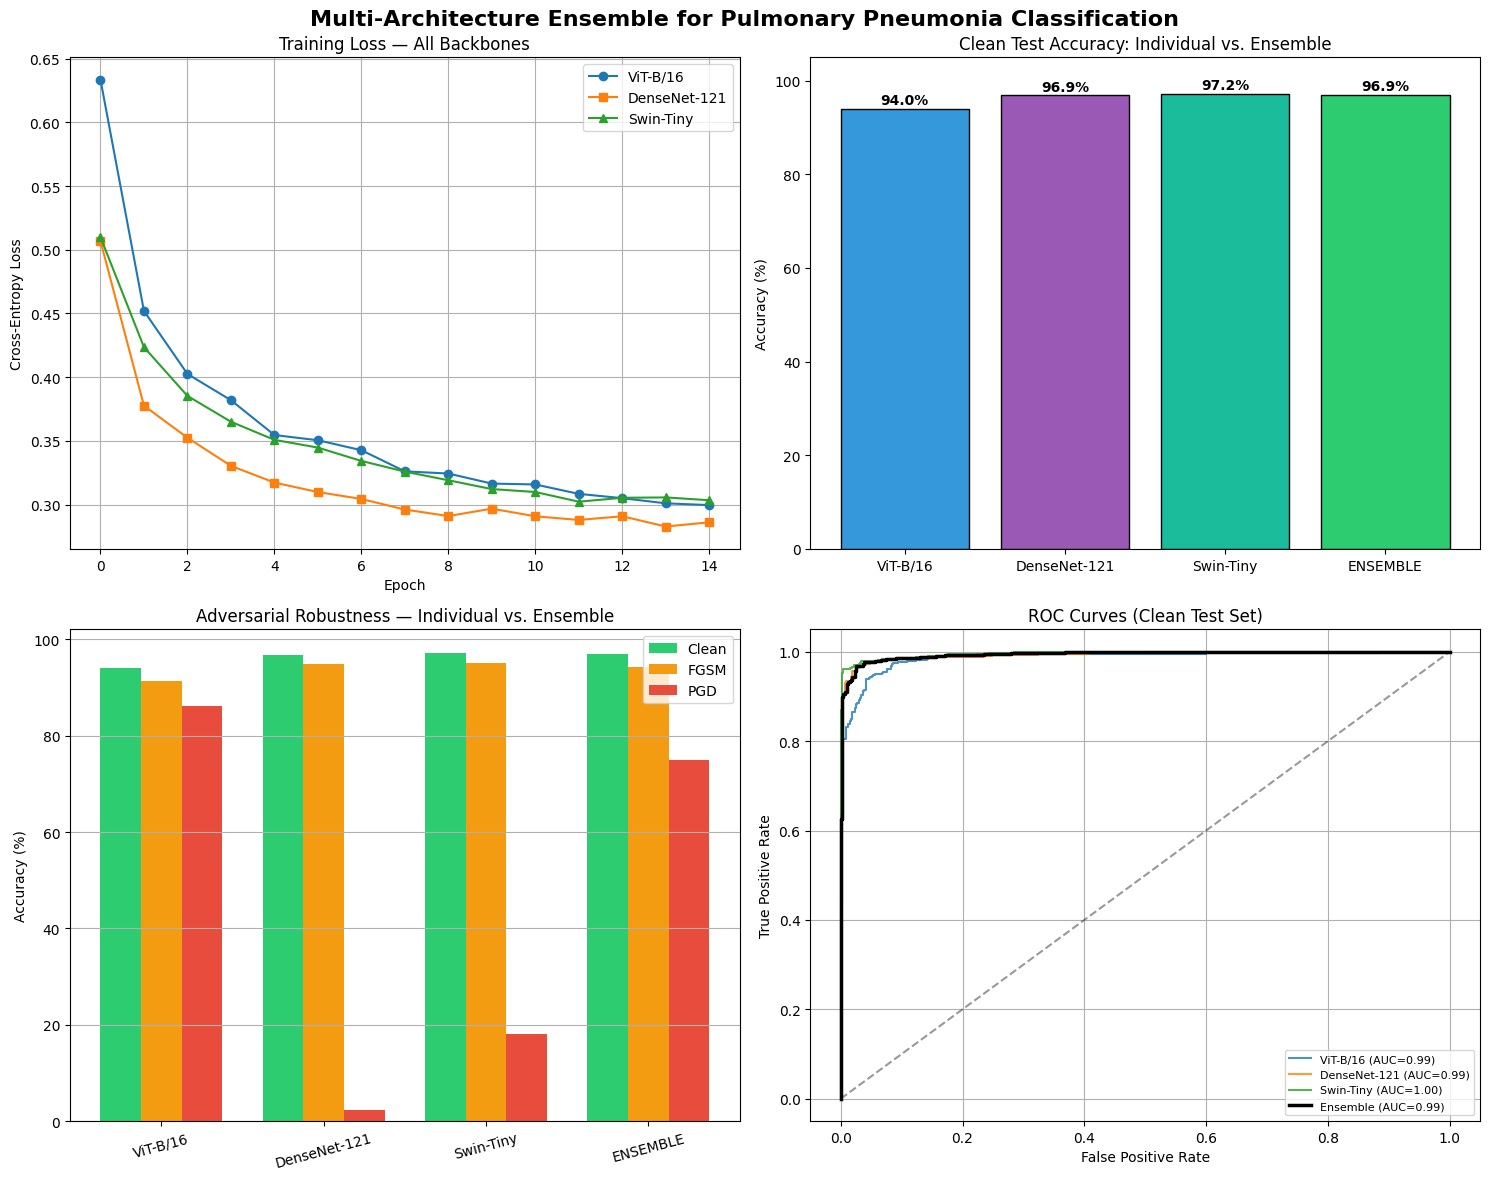

✅ Graphical ensemble comparison saved.


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Multi-Architecture Ensemble for Pulmonary Pneumonia Classification', fontsize=16, fontweight='bold')

# Top-left: training loss curves for all three models
ax = axes[0][0]
ax.plot(vit_history['train_loss'], label='ViT-B/16', marker='o')
ax.plot(densenet_history['train_loss'], label='DenseNet-121', marker='s')
ax.plot(swin_history['train_loss'], label='Swin-Tiny', marker='^')
ax.set_title('Training Loss — All Backbones')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-Entropy Loss')
ax.legend(); ax.grid(True)

# Top-right: clean accuracy bar chart, individual vs ensemble
ax = axes[0][1]
model_names = list(individual_results.keys()) + ['ENSEMBLE']
clean_accs = [individual_results[n]['Clean']['acc'] for n in individual_results] + [ensemble_results['Clean']['acc']]
colors = ['#3498db', '#9b59b6', '#1abc9c', '#2ecc71']
bars = ax.bar(model_names, clean_accs, color=colors, edgecolor='black')
ax.set_title('Clean Test Accuracy: Individual vs. Ensemble')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, 105)
for bar, val in zip(bars, clean_accs):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f'{val:.1f}%', ha='center', fontweight='bold')

# Bottom-left: adversarial robustness, grouped bars
ax = axes[1][0]
import numpy as _np
x = _np.arange(len(model_names))
width = 0.25
fgsm_accs = [individual_results[n]['FGSM']['acc'] for n in individual_results] + [ensemble_results['FGSM']['acc']]
pgd_accs = [individual_results[n]['PGD']['acc'] for n in individual_results] + [ensemble_results['PGD']['acc']]
ax.bar(x - width, clean_accs, width, label='Clean', color='#2ecc71')
ax.bar(x, fgsm_accs, width, label='FGSM', color='#f39c12')
ax.bar(x + width, pgd_accs, width, label='PGD', color='#e74c3c')
ax.set_xticks(x); ax.set_xticklabels(model_names, rotation=15)
ax.set_title('Adversarial Robustness — Individual vs. Ensemble')
ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(True, axis='y')

# Bottom-right: ROC curves, individual models + ensemble (clean)
ax = axes[1][1]
for name, res in individual_results.items():
    fpr, tpr, _ = roc_curve(res['Clean']['true'], res['Clean']['probs'])
    ax.plot(fpr, tpr, label=f'{name} (AUC={res["Clean"]["auroc"]/100:.2f})', alpha=0.8)
fpr_e, tpr_e, _ = roc_curve(ensemble_results['Clean']['true'], ensemble_results['Clean']['probs'])
ax.plot(fpr_e, tpr_e, label=f'Ensemble (AUC={ensemble_results["Clean"]["auroc"]/100:.2f})', color='black', linewidth=2.5)
ax.plot([0,1],[0,1],'k--', alpha=0.4)
ax.set_title('ROC Curves (Clean Test Set)')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.legend(fontsize=8); ax.grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ensemble_pneumonia_results.png', dpi=150)
plt.show()
print('✅ Graphical ensemble comparison saved.')


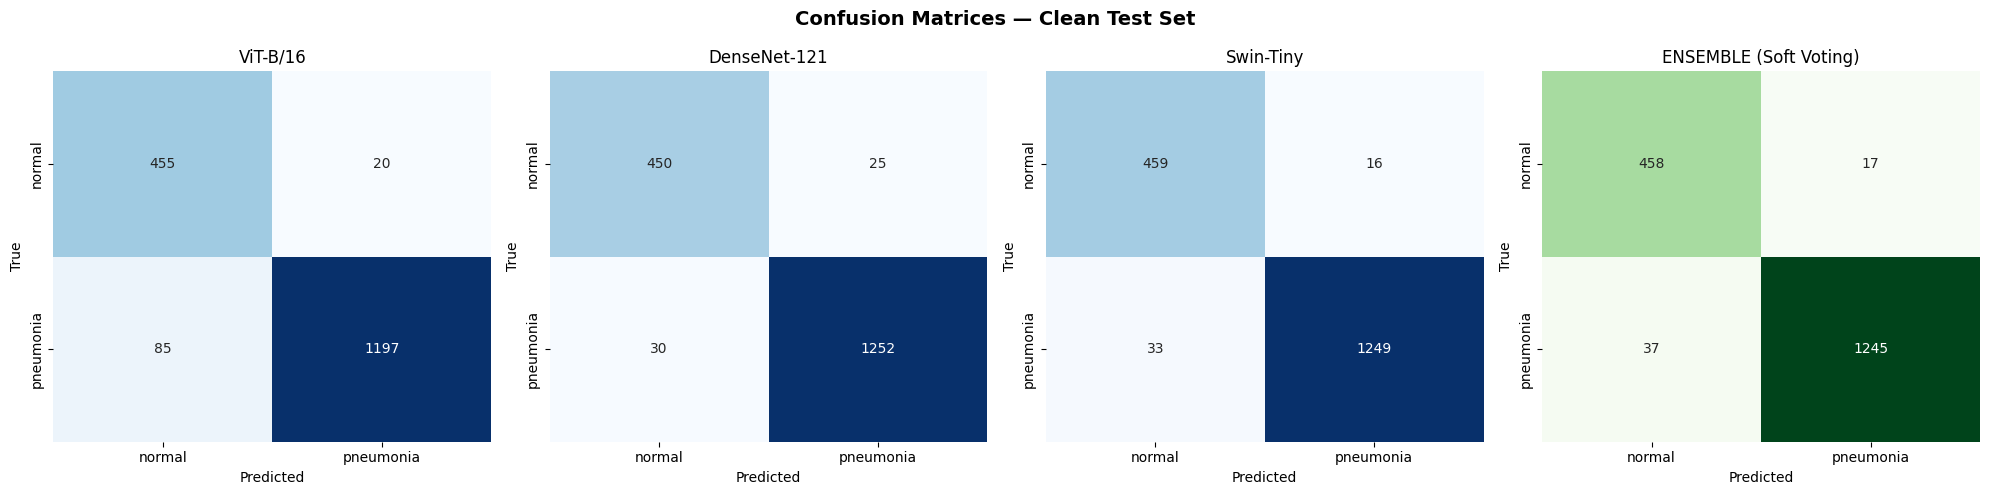

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle('Confusion Matrices — Clean Test Set', fontsize=14, fontweight='bold')

for ax, (name, res) in zip(axes[:3], individual_results.items()):
    cm = confusion_matrix(res['Clean']['true'], res['Clean']['preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
    ax.set_title(name)
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')

cm_e = confusion_matrix(ensemble_results['Clean']['true'], ensemble_results['Clean']['preds'])
sns.heatmap(cm_e, annot=True, fmt='d', cmap='Greens', ax=axes[3], xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
axes[3].set_title('ENSEMBLE (Soft Voting)')
axes[3].set_ylabel('True'); axes[3].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ensemble_confusion_matrices.png', dpi=150)
plt.show()


## 13. Classification Reports (Precision / Recall / F1)

Per-class precision/recall/F1 for each backbone and for the ensemble on the clean test set — useful for spotting whether the ensemble specifically improves recall on PNEUMONIA (the clinically costlier miss) versus any individual model.

In [ ]:
for name, res in individual_results.items():
    print(f'--- {name} (Clean Test Set) ---')
    print(classification_report(res['Clean']['true'], res['Clean']['preds'], target_names=['NORMAL', 'PNEUMONIA']))

print('--- ENSEMBLE (Soft Voting, Clean Test Set) ---')
print(classification_report(ensemble_results['Clean']['true'], ensemble_results['Clean']['preds'], target_names=['NORMAL', 'PNEUMONIA']))


--- ViT-B/16 (Clean Test Set) ---
              precision    recall  f1-score   support

      NORMAL       0.84      0.96      0.90       475
   PNEUMONIA       0.98      0.93      0.96      1282

    accuracy                           0.94      1757
   macro avg       0.91      0.95      0.93      1757
weighted avg       0.95      0.94      0.94      1757

--- DenseNet-121 (Clean Test Set) ---
              precision    recall  f1-score   support

      NORMAL       0.94      0.95      0.94       475
   PNEUMONIA       0.98      0.98      0.98      1282

    accuracy                           0.97      1757
   macro avg       0.96      0.96      0.96      1757
weighted avg       0.97      0.97      0.97      1757

--- Swin-Tiny (Clean Test Set) ---
              precision    recall  f1-score   support

      NORMAL       0.93      0.97      0.95       475
   PNEUMONIA       0.99      0.97      0.98      1282

    accuracy                           0.97      1757
   macro avg       0.

## 14. Single-Image Inference with the Ensemble

Same clinical-report style as the original notebook's `predict_single_xray`, but now runs the image through all three models and reports both the **soft-voted final diagnosis** and each individual model's vote — useful for spotting disagreement between architectures, which can itself be a signal worth a closer look.

In [ ]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import os

def predict_single_xray_ensemble(image_path,
                                  vit_path=VIT_PATH,
                                  densenet_path=DENSENET_PATH,
                                  swin_path=SWIN_PATH,
                                  weights=None):
    """
    Takes a path to a raw chest X-ray image, runs it through the ViT-B/16,
    DenseNet-121, and Swin-Tiny models, and reports the soft-voted ensemble
    diagnosis alongside each individual model's prediction.
    """

    inference_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    if not os.path.exists(image_path):
        print(f"❌ Error: Image file not found at '{image_path}'")
        return

    try:
        raw_img = Image.open(image_path).convert('RGB')
    except Exception as e:
        print(f"❌ Error opening image file: {e}")
        return

    input_tensor = inference_transform(raw_img).unsqueeze(0).to(device)

    # Build fresh model instances and load each checkpoint
    inf_vit = PneumoniaViT(pretrained_encoder=None).to(device)
    inf_densenet = PneumoniaDenseNet().to(device)
    inf_swin = PneumoniaSwin().to(device)

    for path, model, label in [(vit_path, inf_vit, 'ViT-B/16'),
                                (densenet_path, inf_densenet, 'DenseNet-121'),
                                (swin_path, inf_swin, 'Swin-Tiny')]:
        if not os.path.exists(path):
            print(f"❌ Error: Trained weights file not found at '{path}' for {label}. Check your path!")
            return
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()

    inf_models = {'ViT-B/16': inf_vit, 'DenseNet-121': inf_densenet, 'Swin-Tiny': inf_swin}

    CLASS_NAMES = ['NORMAL', 'PNEUMONIA']
    individual_votes = {}
    with torch.inference_mode():
        for name, model in inf_models.items():
            outputs = model(input_tensor)
            probs = torch.softmax(outputs, dim=1)[0]
            individual_votes[name] = probs.cpu()

        ensemble_probs = ensemble_predict_proba(inf_models, input_tensor, weights=weights)[0]

    predicted_class_idx = torch.argmax(ensemble_probs).item()
    predicted_label = CLASS_NAMES[predicted_class_idx]
    confidence_score = ensemble_probs[predicted_class_idx].item() * 100

    print("=" * 58)
    print("🩻 AUTOMATED PATIENT RADIOLOGY ANALYSIS REPORT (ENSEMBLE)")
    print("=" * 58)
    print(f"📂 File Evaluated     : {os.path.basename(image_path)}")
    diagnosis_color = '\033[1;31m' if predicted_label == 'PNEUMONIA' else '\033[1;32m'
    print(f"🩺 Ensemble Diagnosis : {diagnosis_color}{predicted_label}\033[0m")
    print(f"📊 Ensemble Confidence: {confidence_score:.2f}%")
    print(f"📋 Ensemble Distributions: NORMAL ({ensemble_probs[0]*100:.1f}%) | PNEUMONIA ({ensemble_probs[1]*100:.1f}%)")
    print("-" * 58)
    print("🔬 Individual Model Votes:")
    for name, probs in individual_votes.items():
        idx = torch.argmax(probs).item()
        print(f"   {name:<14}: {CLASS_NAMES[idx]:<10} (NORMAL {probs[0]*100:.1f}% | PNEUMONIA {probs[1]*100:.1f}%)")
    print("=" * 58)

    return predicted_label, confidence_score, individual_votes


TEST_IMAGE_PATH = '/content/chest_abnormal_0016.jpg'
predict_single_xray_ensemble(TEST_IMAGE_PATH)


❌ Error: Image file not found at '/content/chest_abnormal_0016.jpg'


## 15. Download Known Test Samples & Validate Ensemble Inference

In [ ]:
from google.colab import files
import os

print("Please upload your kaggle.json file:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("✅ Kaggle API successfully configured!")


Please upload your kaggle.json file:


Saving kaggle (2).json to kaggle (2) (1).json
mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ Kaggle API successfully configured!


In [ ]:
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

!unzip -q chest-xray-pneumonia.zip "chest_xray/test/NORMAL/IM-0001-0001.jpeg" -d .
!unzip -q chest-xray-pneumonia.zip "chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg" -d .

!mv chest_xray/test/NORMAL/IM-0001-0001.jpeg /content/test_normal_sample.jpeg
!mv chest_xray/test/PNEUMONIA/person100_bacteria_475.jpeg /content/test_pneumonia_sample.jpeg

!rm -rf chest_xray

print("✅ Kaggle test samples successfully downloaded!")
print(" -> Normal sample path   : /content/test_normal_sample.jpeg")
print(" -> Pneumonia sample path: /content/test_pneumonia_sample.jpeg")


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
✅ Kaggle test samples successfully downloaded!
 -> Normal sample path   : /content/test_normal_sample.jpeg
 -> Pneumonia sample path: /content/test_pneumonia_sample.jpeg


In [ ]:
print("Testing a known NORMAL image with the ensemble:")
predict_single_xray_ensemble('/content/test_normal_sample.jpeg')

print("\n" + "=" * 58 + "\n")

print("Testing a known PNEUMONIA image with the ensemble:")
predict_single_xray_ensemble('/content/test_pneumonia_sample.jpeg')


Testing a known NORMAL image with the ensemble:
🩻 AUTOMATED PATIENT RADIOLOGY ANALYSIS REPORT (ENSEMBLE)
📂 File Evaluated     : test_normal_sample.jpeg
🩺 Ensemble Diagnosis : NORMAL
📊 Ensemble Confidence: 93.27%
📋 Ensemble Distributions: NORMAL (93.3%) | PNEUMONIA (6.7%)
----------------------------------------------------------
🔬 Individual Model Votes:
   ViT-B/16      : NORMAL     (NORMAL 93.7% | PNEUMONIA 6.3%)
   DenseNet-121  : NORMAL     (NORMAL 91.1% | PNEUMONIA 8.9%)
   Swin-Tiny     : NORMAL     (NORMAL 95.1% | PNEUMONIA 4.9%)


Testing a known PNEUMONIA image with the ensemble:
🩻 AUTOMATED PATIENT RADIOLOGY ANALYSIS REPORT (ENSEMBLE)
📂 File Evaluated     : test_pneumonia_sample.jpeg
🩺 Ensemble Diagnosis : PNEUMONIA
📊 Ensemble Confidence: 89.69%
📋 Ensemble Distributions: NORMAL (10.3%) | PNEUMONIA (89.7%)
----------------------------------------------------------
🔬 Individual Model Votes:
   ViT-B/16      : PNEUMONIA  (NORMAL 8.7% | PNEUMONIA 91.3%)
   DenseNet-121  : PNEUMON

('PNEUMONIA',
 89.68924880027771,
 {'ViT-B/16': tensor([0.0866, 0.9134]),
  'DenseNet-121': tensor([0.1885, 0.8115]),
  'Swin-Tiny': tensor([0.0342, 0.9658])})